### Magnetostatics



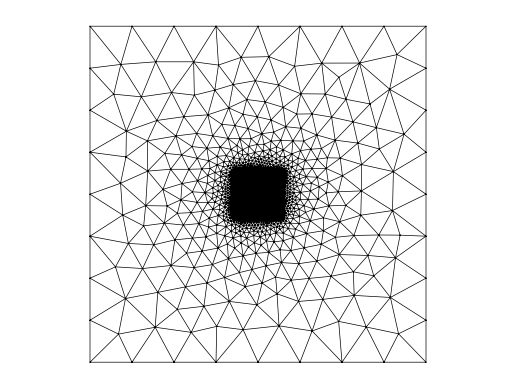

In [6]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/pm-in-core/c_core_pm.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

Get triangualr elements and first order basis functions. We need to define own basis for 'pm-nort/south' and 'iron' domains
Also permeability is different in iron

In [7]:
e = ElementTriP1()
basis = Basis(mesh, e)
basis_core = basis.with_elements(mesh.subdomains["core"])
basis_air = basis.with_elements(mesh.subdomains["air"])
basis_pm_N = basis.with_elements(mesh.subdomains["magnet_N"])
basis_pm_S = basis.with_elements(mesh.subdomains["magnet_S"])


print(basis_core)
print(basis_air)
print(basis_pm_N)
print(basis_pm_S)


<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 6522
  Number of DOFs: 5383
  Size: 1408752 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2328
  Number of DOFs: 5383
  Size: 502848 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 940
  Number of DOFs: 5383
  Size: 203040 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 942
  Number of DOFs: 5383
  Size: 203472 B


Bilinear and linear forms, from weak formulation


In [44]:

# w.mu little coonfusing but it just wraps the permeability to some variable w

@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def magnet_rhs(v, w):

    Brx = w.Brx
    Bry = w.Bry
    nu = w.nu      # = 1/mu

    return nu * (
        Brx * v.grad[1]
        -
        Bry * v.grad[0]
    )


mu0 = 4 * np.pi * 1e-7

mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0

S_mat = laplace.assemble(basis_air, mu=mu_air)
S_mat += laplace.assemble(basis_pm_N, mu=mu_air)
S_mat += laplace.assemble(basis_pm_S, mu=mu_air)
S_mat += laplace.assemble(basis_core, mu=mu_iron)

# Remanent flux. 
Brx = 1.2
Bry = 0

# North pole pointing left,  so negative remanence to Bx
b = magnet_rhs.assemble(
    basis_pm_N,
    Brx=-Brx,
    Bry=Bry,
    nu=1/mu_pm
)

# South pole pointing right, so positive x direction is the remanence
b += magnet_rhs.assemble(
    basis_pm_S,
    Brx=Brx,
    Bry=Bry,
    nu=1/mu_pm
)

Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [45]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

Solve & Visualize Az = vector pootential

<Axes: title={'center': 'Magnetic Vector Potential $A_z$'}>

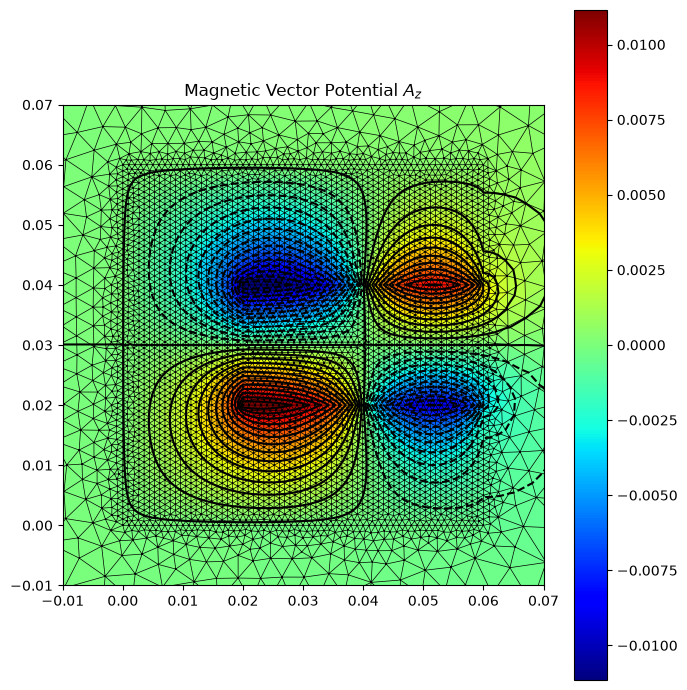

In [59]:
A_z = solve(S_mat, b)

cm = 1.0 / 100.0
w = 6 * cm
h = w
margin = 1.0 * cm

import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot


cm = 1.0 / 100.0
w = 6 * cm
h = w
margin = 1.0 * cm

fig, ax = plt.subplots(figsize=(7,7))

plot(
    mesh,
    A_z,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    mesh,
    A_z,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_xlim(-margin,w+margin)
ax.set_ylim(-margin,h+margin)

ax.set_aspect("equal")
ax.set_title(r"Magnetic Vector Potential $A_z$")

plt.tight_layout()
from skfem.visuals.matplotlib import draw

draw(mesh, ax=ax)

Now we compute Bx and By with partial derivatives to plot B field

In [29]:
# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)


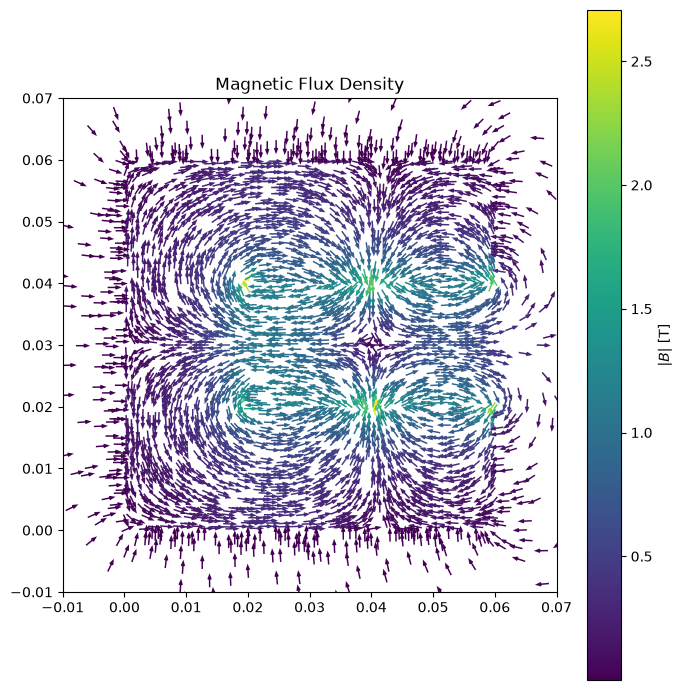

In [55]:
import numpy as np
import matplotlib.pyplot as plt



cm = 1.0 / 100.0
w = 6 * cm
h = w
margin = 1.0 * cm

eps = 1e-14

Bx_plot = Bx_elem / (Bnorm_elem + eps)
By_plot = By_elem / (Bnorm_elem + eps)

fig, ax = plt.subplots(figsize=(7,7))

step = 3

q = ax.quiver(
    centers[0][::step],
    centers[1][::step],
    Bx_plot[::step],
    By_plot[::step],
    Bnorm_elem[::step],
    cmap="viridis",
    pivot="mid",
    scale=35,
    width=0.003,
    headwidth=3,
    headlength=4
)

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

ax.set_xlim(-margin, w+margin)
ax.set_ylim(-margin, h+margin)
ax.set_aspect("equal")

ax.set_title("Magnetic Flux Density")

plt.tight_layout()

<Axes: title={'center': '$|B|$'}>

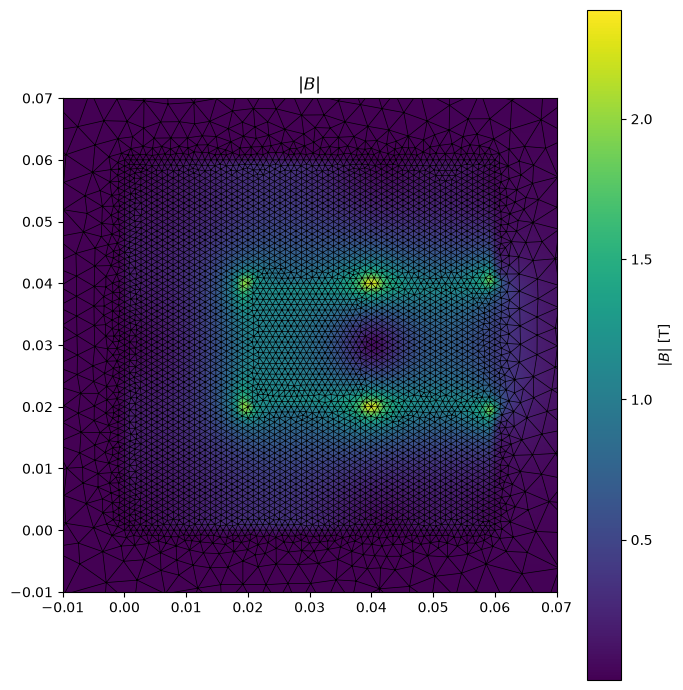

In [58]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri



cm = 1.0 / 100.0
w = 6 * cm
h = w
margin = 1.0 * cm

triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

# convert element values to nodal values
Bnode = np.zeros(mesh.p.shape[1])
count = np.zeros(mesh.p.shape[1])

for elem, tri in enumerate(mesh.t.T):
    for node in tri:
        Bnode[node] += Bnorm_elem[elem]
        count[node] += 1

Bnode /= count

fig, ax = plt.subplots(figsize=(7,7))

c = ax.tripcolor(
    triang,
    Bnode,
    shading="gouraud",
    cmap="viridis"
)

fig.colorbar(c, ax=ax, label=r"$|B|$ [T]")

ax.set_xlim(-margin,w+margin)
ax.set_ylim(-margin,h+margin)

ax.set_aspect("equal")

ax.set_title(r"$|B|$")

plt.tight_layout()

from skfem.visuals.matplotlib import draw

draw(mesh, ax=ax)

Bnorm for each element


Number of air elements: 2328
Min |B| in air : 4.621719e-05 T
Max |B| in air : 1.294271e+00 T
Mean |B| in air: 4.141702e-02 T


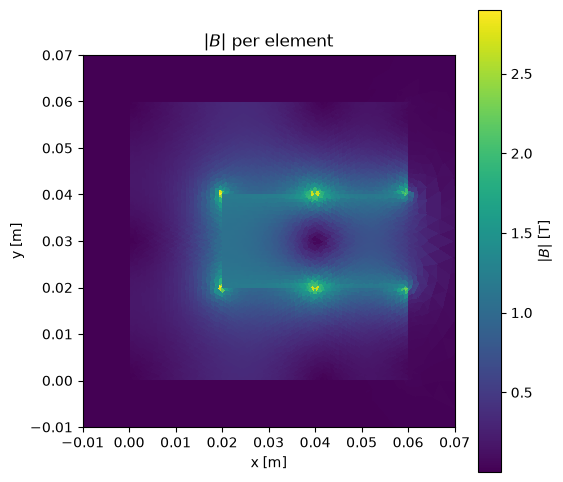

In [32]:
Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)


# Element indices belonging to the air region
air_elems = basis_air.tind

print(f"Number of air elements: {len(air_elems)}")

B_air = Bnorm_elem[air_elems]

print(f"Min |B| in air : {B_air.min():.6e} T")
print(f"Max |B| in air : {B_air.max():.6e} T")
print(f"Mean |B| in air: {B_air.mean():.6e} T")

import matplotlib.tri as mtri

tri = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

fig, ax = plt.subplots(figsize=(6,6))

pc = ax.tripcolor(
    tri,
    facecolors=Bnorm_elem,
    edgecolors='none',
    cmap='viridis'
)

ax.set_title(r"$|B|$ per element")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal")
cm = 1.0 / 100.0
w = 6 * cm
h = w
margin = 1.0 * cm
ax.set_xlim(-margin, w + margin)
ax.set_ylim(-margin, h + margin)

fig.colorbar(pc, ax=ax, label=r"$|B|$ [T]")

plt.show()

#### Plotting B for each node

The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.


In [41]:
# Build connectivity. This help to find elements that share nodes. Then we know which gradient values to average for specific node.
node_to_elements = [[] for _ in range(mesh.nvertices)]

for elem in range(mesh.nelements):

    for node in mesh.t[:, elem]:

        node_to_elements[node].append(elem)


Bx_node = np.zeros(mesh.nvertices)
By_node = np.zeros(mesh.nvertices)



for node in range(mesh.nvertices):
    # all elements that share 'node'
    elems = node_to_elements[node]

    # nodal averaged values for Bx and By
    Bx_node[node] = np.mean(Bx_elem[elems])
    By_node[node] = np.mean(By_elem[elems])

B_norm = np.sqrt(Bx_node**2+By_node**2)

print(Bx_node.shape)
print(B_norm.shape)


(5383,)
(5383,)


Compute B-norm and plot



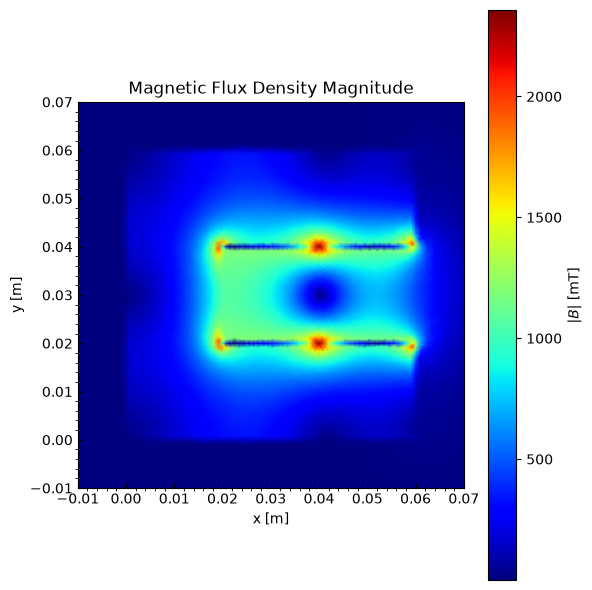

In [ ]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

def visualize():

    # Geometry dimensions
    cm = 1.0 / 100.0
    w = 6 * cm
    h = w
    margin = 1.0 * cm

    fig, ax = plt.subplots(figsize=(6, 6))

    plot(
        mesh,
        1000 * B_norm,
        ax=ax,
        shading='gouraud',
        colorbar=True
    )

    # Zoom into the region around the C-core
    ax.set_xlim(-margin, w + margin)
    ax.set_ylim(-margin, h + margin)

    ax.set_title("Magnetic Flux Density Magnitude")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

    ax.tick_params(direction='in')
    ax.minorticks_on()

    # Label the colorbar
    cbar = fig.axes[-1]
    cbar.set_ylabel(r"$|B|$ [mT]")

    fig.tight_layout()
    draw(mesh, ax=ax)


if __name__ == "__main__":
    visualize()
    plt.show()
    